# Genre Classification: TF-IDF Weighted Word2Vec + Logistic Regression

This notebook combines the strengths of TF-IDF (which weighs distinctive vocabulary) and Word2Vec (which captures semantic similarity) to build a richer feature representation for genre classification.

**The core idea:** Instead of averaging Word2Vec vectors uniformly across a song, weight each word's vector by its TF-IDF score. This down-weights common words and up-weights distinctive ones, often producing a stronger feature than either method alone.

**Pipeline:**
1. Load and preprocess lyrics
2. Train/test split (stratified)
3. Train Word2Vec on training lyrics only (no leakage)
4. Fit TF-IDF on training lyrics only
5. Compute TF-IDF weighted Word2Vec vectors per song
6. Train Logistic Regression with class balancing
7. Evaluate with accuracy, macro-F1, classification report, confusion matrix

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK resources (only needed once)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 2. Load Data

Adjust the path and column names to match your dataset. Expected columns: a lyrics text column and a genre label column.

In [7]:
# TODO: update this path and column names to match your dataset
DATA_PATH = '/Users/astasolbjarkadottir/Desktop/Machine Learning/Final Project/Connor/clean version/dataset.csv'
LYRICS_COL = 'lyrics_cleaned'
GENRE_COL = 'parent_genre'

df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=[LYRICS_COL, GENRE_COL]).reset_index(drop=True)

print(f'Total songs: {len(df)}')
print('\nGenre distribution:')
print(df[GENRE_COL].value_counts())

Total songs: 15372

Genre distribution:
parent_genre
Electronic          4411
Rock                2463
Metal               2261
Folk/Country        1608
Pop                 1424
World/Regional       857
Soul/Funk            784
Asian Pop            481
Reggae/Caribbean     431
Jazz & Blues         286
Classical            222
Hip-Hop & R&B        144
Name: count, dtype: int64


## 3. Preprocessing

Two tokenization paths because TF-IDF and Word2Vec want different things:
- **TF-IDF tokens**: lowercased, stopwords removed, lemmatized, alpha-only
- **Word2Vec tokens**: lowercased, stopwords KEPT (context matters), alpha-only

For the combined TF-IDF-weighted Word2Vec, we use a single shared tokenization (TF-IDF style) so the vocabularies align. We drop stopwords because their TF-IDF weight would be ~0 anyway and keeping them just bloats the vocab.

In [8]:
# Standard English stopwords + lyric-specific filler words
stop_words = set(stopwords.words('english'))
lyric_filler = {
    'yeah', 'oh', 'ooh', 'uh', 'na', 'la', 'hey', 'mmm', 'whoa', 'woah',
    'verse', 'chorus', 'bridge', 'intro', 'outro', 'pre', 'hook',
}
stop_words = stop_words.union(lyric_filler)

lemmatizer = WordNetLemmatizer()

def tokenize(text):
    """Lowercase, tokenize, drop non-alpha, drop stopwords, lemmatize."""
    if not isinstance(text, str):
        return []
    tokens = word_tokenize(text.lower())
    return [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t.isalpha() and t not in stop_words
    ]

df['tokens'] = df[LYRICS_COL].apply(tokenize)

# Drop songs that ended up with no tokens after preprocessing
df = df[df['tokens'].apply(len) > 0].reset_index(drop=True)
print(f'Songs after preprocessing: {len(df)}')
print(f'Avg tokens per song: {df["tokens"].apply(len).mean():.1f}')

Songs after preprocessing: 15372
Avg tokens per song: 148.4


## 4. Train/Test Split

Stratified split keeps class proportions consistent in train and test. Important given the genre imbalance.

In [9]:
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    stratify=df[GENRE_COL],
    random_state=RANDOM_STATE,
)
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(f'Train: {len(df_train)}  Test: {len(df_test)}')

Train: 12297  Test: 3075


## 5. Train Word2Vec

Train on the **training set only** to avoid information leakage from the test set. Skip-gram (`sg=1`) is generally better than CBOW for smaller corpora and rare-word quality, both of which apply to lyrics.

In [10]:
VECTOR_SIZE = 200

w2v_model = Word2Vec(
    sentences=df_train['tokens'].tolist(),
    vector_size=VECTOR_SIZE,
    window=5,
    min_count=2,       # drop tokens that appear only once
    workers=4,
    sg=1,              # skip-gram
    epochs=15,
    negative=10,
    seed=RANDOM_STATE,
)

print(f'Vocab size: {len(w2v_model.wv)}')
print(f'Vector size: {w2v_model.vector_size}')

# Quick sanity check — neighbors should be semantically related
for word in ['love', 'fire', 'night']:
    if word in w2v_model.wv:
        print(f'\nNeighbors of "{word}":')
        for neighbor, score in w2v_model.wv.most_similar(word, topn=5):
            print(f'  {neighbor:<20} {score:.3f}')

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocab size: 22555
Vector size: 200

Neighbors of "love":
  looooove             0.565
  ophelia              0.558
  lololololove         0.551
  loathe               0.540
  unrated              0.540

Neighbors of "fire":
  winres               0.539
  bitbitbitbitbitbit   0.522
  rubadubadub          0.508
  yeahahahah           0.504
  stoking              0.500

Neighbors of "night":
  ohohah               0.548
  practicin            0.543
  dumdumdadadum        0.541
  shive                0.534
  reallyreally         0.527


## 6. Fit TF-IDF

Fit TF-IDF on the training set only. We use `tokenizer=lambda x: x` and `preprocessor=lambda x: x` to tell sklearn that the input is already tokenized.

In [11]:
tfidf = TfidfVectorizer(
    tokenizer=lambda x: x,
    preprocessor=lambda x: x,
    token_pattern=None,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)
tfidf.fit(df_train['tokens'])

# Map word -> idf weight for fast lookup
vocab = tfidf.vocabulary_
idf = tfidf.idf_
word_to_idf = {word: idf[idx] for word, idx in vocab.items()}

print(f'TF-IDF vocab size: {len(vocab)}')

TF-IDF vocab size: 17840


## 7. Build TF-IDF Weighted Word2Vec Vectors

For each song, compute a weighted average of its word vectors where weights come from TF-IDF. Words must be in *both* the Word2Vec vocabulary and the TF-IDF vocabulary to contribute.

Songs that end up with no overlapping vocabulary get a zero vector (rare in practice).

In [12]:
def tfidf_weighted_w2v(tokens, w2v_model, word_to_idf, dim):
    """Weighted average of Word2Vec vectors using TF-IDF weights."""
    if not tokens:
        return np.zeros(dim, dtype=np.float32)

    # Compute term frequency in this document
    tf = {}
    for t in tokens:
        tf[t] = tf.get(t, 0) + 1
    n = len(tokens)

    weighted_sum = np.zeros(dim, dtype=np.float32)
    weight_total = 0.0

    for word, count in tf.items():
        if word in w2v_model.wv and word in word_to_idf:
            weight = (count / n) * word_to_idf[word]   # tf * idf
            weighted_sum += weight * w2v_model.wv[word]
            weight_total += weight

    if weight_total == 0:
        return np.zeros(dim, dtype=np.float32)
    return weighted_sum / weight_total


def build_matrix(df_subset):
    return np.array([
        tfidf_weighted_w2v(tokens, w2v_model, word_to_idf, VECTOR_SIZE)
        for tokens in df_subset['tokens']
    ], dtype=np.float32)


X_train = build_matrix(df_train)
X_test = build_matrix(df_test)
y_train = df_train[GENRE_COL].values
y_test = df_test[GENRE_COL].values

print(f'X_train: {X_train.shape}  dtype: {X_train.dtype}')
print(f'X_test:  {X_test.shape}  dtype: {X_test.dtype}')

# Sanity check: how many songs got all-zero vectors?
zero_train = (np.linalg.norm(X_train, axis=1) == 0).sum()
zero_test = (np.linalg.norm(X_test, axis=1) == 0).sum()
print(f'All-zero vectors — train: {zero_train}, test: {zero_test}')

X_train: (12297, 200)  dtype: float32
X_test:  (3075, 200)  dtype: float32
All-zero vectors — train: 0, test: 0


## 8. Train Logistic Regression

`class_weight='balanced'` is critical given the genre imbalance — it tells the model to weigh rare classes proportionally so they don't get drowned out by Electronic and Rock.

We also standardize features, which helps Logistic Regression converge faster on dense embeddings.

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

clf = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        C=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

clf.fit(X_train, y_train)
preds = clf.predict(X_test)

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 9. Evaluation

In [14]:
acc = accuracy_score(y_test, preds)
macro_f1 = f1_score(y_test, preds, average='macro')
weighted_f1 = f1_score(y_test, preds, average='weighted')

print(f'Accuracy:    {acc:.3f}')
print(f'Macro F1:    {macro_f1:.3f}')
print(f'Weighted F1: {weighted_f1:.3f}')
print()
print('Classification Report:')
print(classification_report(y_test, preds))

Accuracy:    0.326
Macro F1:    0.294
Weighted F1: 0.325

Classification Report:
                  precision    recall  f1-score   support

       Asian Pop       0.27      0.47      0.34        96
       Classical       0.06      0.30      0.10        44
      Electronic       0.50      0.18      0.26       882
    Folk/Country       0.46      0.51      0.48       322
   Hip-Hop & R&B       0.08      0.52      0.14        29
    Jazz & Blues       0.07      0.30      0.12        57
           Metal       0.56      0.65      0.60       452
             Pop       0.18      0.20      0.19       285
Reggae/Caribbean       0.32      0.44      0.37        86
            Rock       0.25      0.11      0.15       493
       Soul/Funk       0.14      0.19      0.16       157
  World/Regional       0.56      0.66      0.61       172

        accuracy                           0.33      3075
       macro avg       0.29      0.38      0.29      3075
    weighted avg       0.39      0.33      0.33

## 10. Confusion Matrix

This shows exactly which genres get confused with which. Look for off-diagonal hot spots — Rock↔Metal and Pop↔everything-else are common confusions in lyric-based classifiers.

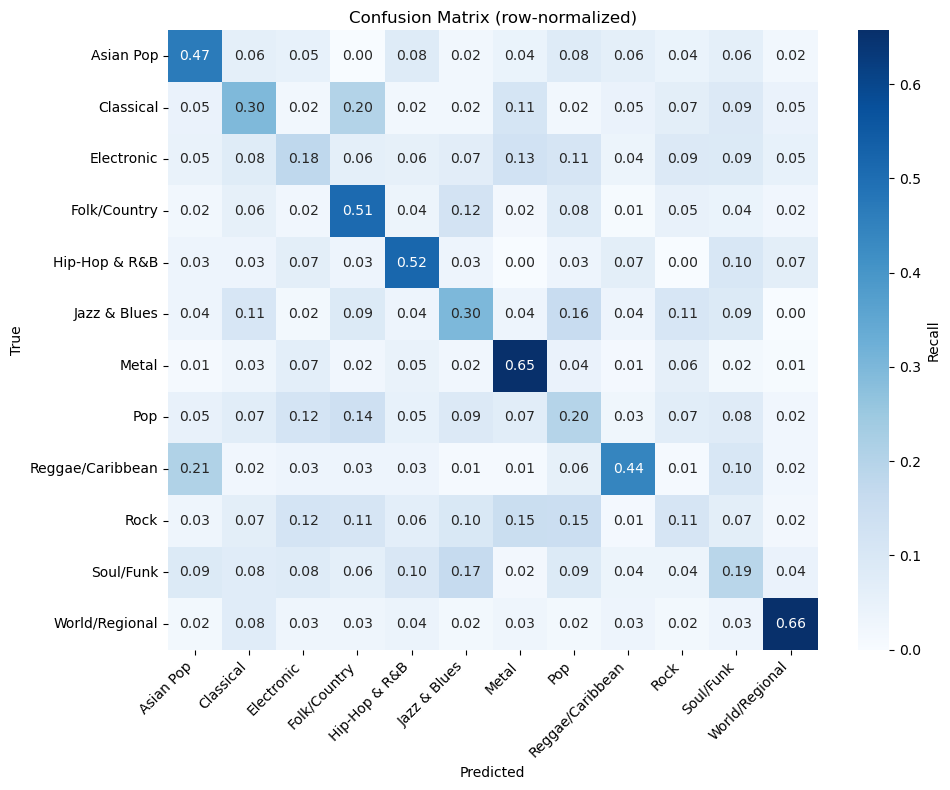

In [15]:
labels = sorted(df[GENRE_COL].unique())
cm = confusion_matrix(y_test, preds, labels=labels, normalize='true')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={'label': 'Recall'},
    ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix (row-normalized)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 11. Compare Against Plain Word2Vec Averaging (Optional)

To see whether TF-IDF weighting actually helped, compare to plain mean-pooled Word2Vec. If the weighted version isn't meaningfully better, you've learned something useful about your data.

In [16]:
def avg_w2v(tokens, w2v_model, dim):
    if not tokens:
        return np.zeros(dim, dtype=np.float32)
    vectors = [w2v_model.wv[w] for w in tokens if w in w2v_model.wv]
    if not vectors:
        return np.zeros(dim, dtype=np.float32)
    return np.mean(vectors, axis=0).astype(np.float32)

X_train_avg = np.array([avg_w2v(t, w2v_model, VECTOR_SIZE) for t in df_train['tokens']], dtype=np.float32)
X_test_avg = np.array([avg_w2v(t, w2v_model, VECTOR_SIZE) for t in df_test['tokens']], dtype=np.float32)

clf_avg = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        max_iter=2000, class_weight='balanced', C=1.0,
        random_state=RANDOM_STATE, n_jobs=-1,
    )),
])
clf_avg.fit(X_train_avg, y_train)
preds_avg = clf_avg.predict(X_test_avg)

print('--- Plain Mean Word2Vec ---')
print(f'Accuracy:  {accuracy_score(y_test, preds_avg):.3f}')
print(f'Macro F1:  {f1_score(y_test, preds_avg, average="macro"):.3f}')
print()
print('--- TF-IDF Weighted Word2Vec ---')
print(f'Accuracy:  {acc:.3f}')
print(f'Macro F1:  {macro_f1:.3f}')

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


--- Plain Mean Word2Vec ---
Accuracy:  0.322
Macro F1:  0.293

--- TF-IDF Weighted Word2Vec ---
Accuracy:  0.326
Macro F1:  0.294


## Notes for Your Write-up

When you fill in the row of your results table, report **Accuracy / Macro-F1** (macro is the honest metric given your class imbalance — Electronic has 30× more samples than Hip-Hop & R&B).

Things worth discussing:
- Whether TF-IDF weighting actually beats plain averaging (it often does, but not always)
- Whether dense Word2Vec features beat sparse TF-IDF features (genre classification often favors sparse — distinctive vocabulary matters)
- Per-class performance: which genres benefit from semantic embeddings, which suffer
- Confusion matrix patterns: Rock↔Metal, Pop↔Soul/Funk, etc.